# plotting.py — Demo Notebook

Quick tour of every function in `plotting.py` using synthetic data.

```
pip install plotly kaleido scikit-learn matplotlib numpy
```

In [11]:
import numpy as np
from plotly_lite.plotting import (
    plotBox, plotCombine, plotScatter,
    plotCompare, plotMap, plotHeatmap,
    plotTrajectory, plotOptimization, viewPCA
)

## 1 · `plotBox` — grouped box plots

In [12]:
rng = np.random.default_rng(0)

box_data = {
    'Model A': rng.normal(loc=0.80, scale=0.05, size=100),
    'Model B': rng.normal(loc=0.75, scale=0.08, size=100),
    'Model C': rng.normal(loc=0.85, scale=0.03, size=100),
}

plotBox(
    box_data,
    title='Accuracy Distribution by Model',
    y_label='Accuracy',
    ylimit=[0.55, 1.0],
)

## 2 · `plotCombine` — multi-series lines with independent x axes

In [13]:
t = np.linspace(0, 2 * np.pi, 200)

combine_data = {
    'sin(t)':   (t, np.sin(t)),
    'cos(t)':   (t, np.cos(t)),
    'sin(2t)':  (t, np.sin(2 * t)),
}

plotCombine(
    combine_data,
    title='Trigonometric Functions',
    x_label='t (radians)',
    y_label='Amplitude',
    mode='lines',
    width=3,
)

## 3 · `plotScatter` — scatter with shared x, multiple y series

In [14]:
x_vals = rng.uniform(0, 10, 200)

scatter_data = {
    'y = x + noise':    x_vals + rng.normal(0, 0.8, 200),
    'y = x² / 10':      x_vals ** 2 / 10 + rng.normal(0, 0.5, 200),
}

plotScatter(
    x_vals,
    scatter_data,
    title='Noisy Scatter Comparison',
    x_label='x',
    y_label='y',
    dot_size=4,
)

## 4 · `plotCompare` — training curves (shared x = epoch)

In [15]:
epochs = np.arange(1, 51)

def fake_loss(start, end, noise=0.02):
    decay = start * np.exp(-0.08 * epochs) + end
    return decay + rng.normal(0, noise, len(epochs))

compare_data = {
    'Train loss':      fake_loss(2.5, 0.10),
    'Validation loss': fake_loss(2.5, 0.20, noise=0.04),
}

plotCompare(
    epochs,
    compare_data,
    title='Training vs Validation Loss',
    x_label='Epoch',
    y_label='Loss',
    width=3,
)

## 5 · `plotMap` — raw heatmap (no interpolation)

In [16]:
# Confusion-matrix style grid
labels = ['Cat', 'Dog', 'Bird', 'Fish']
cm = np.array([
    [50,  3,  1,  0],
    [ 2, 45,  2,  1],
    [ 0,  1, 48,  2],
    [ 1,  0,  3, 46],
], dtype=float)

plotMap(
    z=cm,
    x=labels,
    y=labels,
    title='Confusion Matrix',
    xaxis='Predicted',
    yaxis='Actual',
)

## 6 · `plotHeatmap` — contour plot with heatmap fill

In [17]:
grid_x = np.linspace(-3, 3, 80)
grid_y = np.linspace(-3, 3, 80)
X_grid, Y_grid = np.meshgrid(grid_x, grid_y)

# 2-D Gaussian surface
Z = np.exp(-(X_grid**2 + Y_grid**2) / 2)

plotHeatmap(
    z=Z,
    x=grid_x,
    y=grid_y,
    title='2-D Gaussian Surface',
    xaxis='x',
    yaxis='y',
    ncontours=15,
)

## 7 · `plotTrajectory` — animated 2-D paths

In [18]:
T = 100
evo = np.arange(T)   # frames / time steps

def random_walk(seed):
    rng_w = np.random.default_rng(seed)
    steps = rng_w.normal(0, 0.3, (T, 2))
    return np.cumsum(steps, axis=0)

traj_data = {
    'Agent 1': random_walk(1),
    'Agent 2': random_walk(2),
    'Agent 3': random_walk(3),
}

plotTrajectory(
    evo,
    traj_data,
    title='Random Walk Trajectories',
    x_label='x position',
    y_label='y position',
)

## 8 · `plotOptimization` — loss landscape + optimiser paths

In [19]:
w1 = np.linspace(-2, 2, 80)
w2 = np.linspace(-2, 2, 80)
W1, W2 = np.meshgrid(w1, w2)

# Rosenbrock-inspired loss surface
loss_surface = (1 - W1)**2 + 10 * (W2 - W1**2)**2

# Simulate two optimisers converging toward (1, 1)
def opt_path(start, lr, steps=40):
    path = [np.array(start, dtype=float)]
    for _ in range(steps - 1):
        w = path[-1].copy()
        # Gradient of loss surface
        grad = np.array([
            -2*(1 - w[0]) - 40*w[0]*(w[1] - w[0]**2),
             20*(w[1] - w[0]**2)
        ])
        path.append(w - lr * grad)
    return np.array(path)

opt_paths = {
    'SGD  (lr=0.001)':  opt_path([-1.5, -0.5], lr=0.001),
    'Adam (lr=0.01)':   opt_path([-1.5, -0.5], lr=0.010),
}

plotOptimization(
    z=loss_surface,
    x=w1,
    y=w2,
    paths=opt_paths,
    title='Optimiser Paths on Rosenbrock Surface',
    xaxis='w₁',
    yaxis='w₂',
    legend=True,
)

## 9 · `viewPCA` — 2-D PCA projection (matplotlib)

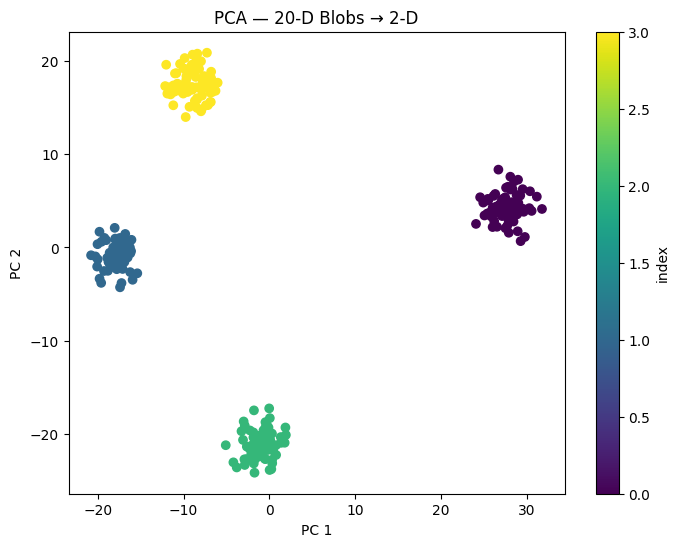

In [20]:
from sklearn.datasets import make_blobs

# 4 clusters in 20-dimensional space
X_high, labels = make_blobs(
    n_samples=300,
    n_features=20,
    centers=4,
    cluster_std=1.5,
    random_state=42,
)

viewPCA(
    X_high,
    index=labels,
    size=(8, 6),
    title='PCA — 20-D Blobs → 2-D',
    x='PC 1',
    y='PC 2',
)